# Phase Field Model - Multi-Armed Bandit Experiments

This notebook reproduces the computational experiments described in our paper, where a simulated slime mold (Physarum polycephalum) navigates a two-armed bandit environment and makes decisions between food sources with different reward frequencies.

**Domain**: Quasi-1D channel (1mm × 0.1mm, 10:1 aspect ratio)

**Experimental conditions**:
- **Baseline**: Equal rewards to validate symmetric exploration
- **Random**: Randomized food distributions
- **Nonbinary**: Differmt reward amounts to test integration

## 1. Setup and Configuration

In [ ]:
# 1.1 Package imports

using Pkg
Pkg.activate(@__DIR__)

using LinearAlgebra
using SparseArrays
using DifferentialEquations
using CairoMakie
using Colors
using CUDA
using Parameters
using Statistics
using Random
using DataFrames
using CSV
using StatsBase
using ImageFiltering

println("✓ Packages loaded")
println("CUDA available: ", CUDA.functional())

In [2]:
# 1.2 Plotting utilities (PNAS style)

# Unit conversion helpers
cm_to_px(cm) = cm * 28.3465  # 1 cm ≈ 28.35 pixels at 72 DPI
cm_to_pt(cm) = cm * 28.3465  # Points for figure sizing

# PNAS-compliant figure styling
function set_pnas_defaults!()
    update_theme!(
        fonts = (regular = "TeX Gyre Heros", bold = "TeX Gyre Heros"),
        fontsize = 8,
        linewidth = 0.75,
        markersize = 3,
        Axis = (
            xlabelsize = 8,
            ylabelsize = 8,
            xticklabelsize = 7,
            yticklabelsize = 7,
            spinewidth = 0.75,
        )
    )
end

set_pnas_defaults!()

# Create figures directory
const FIGDIR = "figures"
if !isdir(FIGDIR)
    mkdir(FIGDIR)
end

# Save figure as SVG
function save_svg(fig, name)
    CairoMakie.save(joinpath(FIGDIR, "$(name).svg"), fig)
end

# Okabe-Ito colorblind-friendly palette
const okabe_ito = [
    colorant"#E69F00",  # Orange
    colorant"#56B4E9",  # Sky blue
    colorant"#009E73",  # Bluish green
    colorant"#F0E442",  # Yellow
    colorant"#0072B2",  # Blue
    colorant"#D55E00",  # Vermillion
    colorant"#CC79A7",  # Reddish purple
    colorant"#000000"   # Black
]

println("✓ Plotting utilities configured")


✓ Plotting utilities configured


In [3]:
# Setup colormap for Q-values

using ColorSchemes

function shared_baseline_cmaps_makie(; n=256, k=32, blend_width=8, inferno_start_offset=32, viridis_max_fraction=0.125)
    @assert 1 ≤ k ≤ n
    @assert blend_width ≥ 0

    # sample both base schemes on [0,1]
    inferno = [get(ColorSchemes.inferno, i/(n-1)) for i in 0:n-1]
    viridis = [get(ColorSchemes.viridis, i/(n-1)) for i in 0:n-1]

    # Sample only from the lowest part of viridis (dark purples), not the blue tones
    viridis_samples = []
    for i in 0:(k-blend_width-1)
        # Map to restricted range [0, viridis_max_fraction]
        frac = i / (k - blend_width - 1) * viridis_max_fraction
        push!(viridis_samples, get(ColorSchemes.viridis, frac))
    end
    
    # Create smooth blend zone
    if blend_width > 0
        blend_zone = []
        for i in 1:(2*blend_width+1)
            α = (i-1) / (2*blend_width)  # 0 to 1 interpolation weight
            # Viridis stays in low range
            vir_frac = viridis_max_fraction * (1 + i/(2*blend_width+1) * 0.2)  # slight progression
            c_vir = get(ColorSchemes.viridis, min(vir_frac, viridis_max_fraction))
            # Inferno starts at offset
            inf_idx = min(inferno_start_offset + i, n)
            c_inf = inferno[inf_idx]
            blended = RGB((1-α)*c_vir.r + α*c_inf.r,
                         (1-α)*c_vir.g + α*c_inf.g,
                         (1-α)*c_vir.b + α*c_inf.b)
            push!(blend_zone, blended)
        end
        # Continue with offset inferno after blend zone
        inferno_tail = inferno[min(inferno_start_offset+2*blend_width+2, n+1):end]
        nutrient_cmap = vcat(viridis_samples, blend_zone, inferno_tail)
    else
        nutrient_cmap = vcat(viridis_samples, inferno[min(inferno_start_offset+1, n+1):end])
    end
    
    thickness_cmap = viridis  # just regular viridis

    return thickness_cmap, nutrient_cmap
end


thickness_cmap, nutrient_cmap = shared_baseline_cmaps_makie(n=256, k=40, blend_width=8, inferno_start_offset=60, viridis_max_fraction=0.08)

#CairoMakie.heatmap!(ax1, thickness; colormap=thickness_cmap, colorrange=(0.0, tmax))
#CairoMakie.heatmap!(ax2, nutrient;  colormap=nutrient_cmap,  colorrange=(0.0, nmax))

(RGB{Float64}[RGB(0.267004, 0.004874, 0.329415), RGB(0.26851, 0.009605, 0.335427), RGB(0.269944, 0.014625, 0.341379), RGB(0.271305, 0.019942, 0.347269), RGB(0.272594, 0.025563, 0.353093), RGB(0.273809, 0.031497, 0.358853), RGB(0.274952, 0.037752, 0.364543), RGB(0.276022, 0.044167, 0.370164), RGB(0.277018, 0.050344, 0.375715), RGB(0.277941, 0.056324, 0.381191)  …  RGB(0.906311, 0.894855, 0.098125), RGB(0.916242, 0.896091, 0.100717), RGB(0.926106, 0.89733, 0.104071), RGB(0.935904, 0.89857, 0.108131), RGB(0.945636, 0.899815, 0.112838), RGB(0.9553, 0.901065, 0.118128), RGB(0.964894, 0.902323, 0.123941), RGB(0.974417, 0.90359, 0.130215), RGB(0.983868, 0.904867, 0.136897), RGB(0.993248, 0.906157, 0.143936)], Any[RGB{Float64}(0.267004, 0.004874, 0.329415), RGB{Float64}(0.26799504516129036, 0.007987303225806453, 0.33337128387096776), RGB{Float64}(0.26896332903225806, 0.011191967741935486, 0.33730859999999996), RGB{Float64}(0.2699069935483871, 0.014495451612903226, 0.3412254), RGB{Float64}(0.27

## 2. Model setup   

In [4]:
## 2.1a Model parameters for calcium dynamics and phase field

# These are the parameters for the bandit experiments.
# For bandit experiments, parameters are calibrated to biological scales (calcium in Molar units).

CUDA.allowscalar(true)

# Calcium dynamics parameters
const C::Float64 = 1e-6      # Maximum calcium concentration (M)
const L::Float64 = 2.5e-3    # Leak rate (s⁻¹)
const K::Float64 = 1.5e-7    # IP₃ receptor deinactivation rate (M⁻¹ s⁻¹)
const A::Float64 = 1.18e-7   # CICR activation threshold (M)
const B::Float64 = 0.9e-7    # Pump inhibition threshold (M)
const P::Float64 = 2.5e-6    # Pump rate (s⁻¹)
const δ::Float64 = 19.0      # IP₃ receptor sensitivity amplification
const k₁₊::Float64 = 2.5e6   # IP₃ receptor inactivation rate (M⁻¹ s⁻¹)
const D::Float64 = 1e-4      # Calcium diffusion coefficient (mm² s⁻¹) [BANDIT PARAM]
const k₄::Float64 = 1e-1     # Calcium decay rate outside cell (s⁻¹)

# Baseline calcium and oscillator states
const c_bar::Float64 = 1e-8  # Baseline calcium concentration (M)
const w_bar::Float64 = 0.75  # Baseline IP₃ receptor active fraction
const h_bar::Float64 = 2e-2  # Baseline thickness (mm)

# Phase field parameters (Allen-Cahn + pressure coupling) [BANDIT PARAMETERS]
const γ::Float64 = 1e-4      # Phase field surface tension (pN)
const α::Float64 = 2.5e-2    # Active pressure strength (pN mm⁻²)
const β::Float64 = 1e2       # Volume constraint strength (pN mm⁻³)
const ϵ::Float64 = 1.8e-2    # Interface width (mm)
const τ::Float64 = 8.0       # Phase field relaxation time (s)

# Thickness field parameters
const k₅::Float64 = 2.5e-1   # Thickness-calcium coupling rate (s⁻¹)
const k₆::Float64 = 2e1      # Thickness-volume coupling rate (s⁻¹)
const k₇::Float64 = 0.0      # (unused in current model)
const k₈::Float64 = 1e-2     # Thickness decay rate (s⁻¹)
const ζ::Float64 = 0.0       # (unused in current model)

┌ Warning: It's not recommended to use allowscalar([true]) to allow scalar indexing.
│ Instead, use `allowscalar() do end` or `@allowscalar` to denote exactly which operations can use scalar operations.
└ @ GPUArraysCore C:\Users\veste\.julia\packages\GPUArraysCore\aNaXo\src\GPUArraysCore.jl:184


0.0

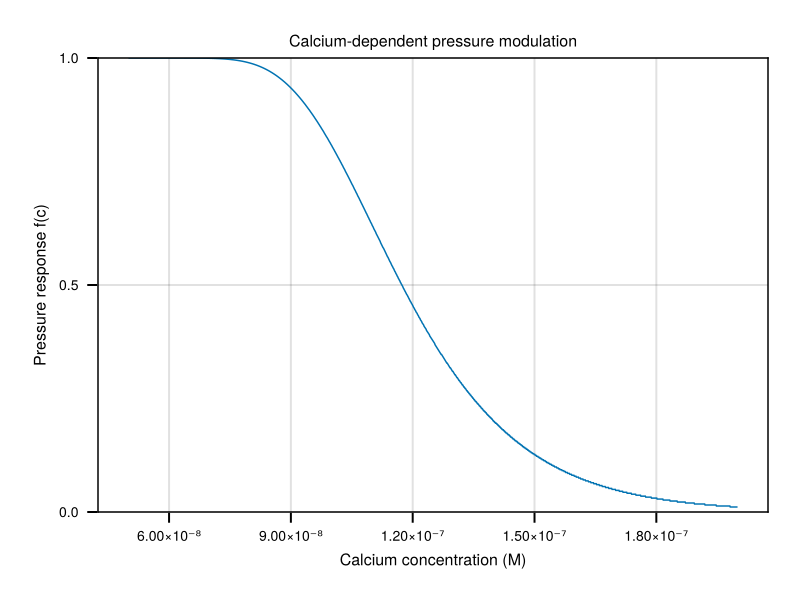

f(c) at high calcium: 0.011040827932318198


In [5]:
## 2.1b Parameters for pressure response function f(c)

# The function f(c) modulates active pressure based on local calcium concentration.
# This creates a sigmoidal response: low calcium → high pressure, high calcium → low pressure.
# Biologically: calcium triggers actomyosin depolymarization, so pressure decreases with [Ca²⁺].

const θ₁::Float64 = 1.0       # Maximum pressure suppression (dimensionless)
const θ₂::Float64 = 0.5e8     # Steepness of calcium response (M⁻¹)
const θ₃::Float64 = 1.1e-7    # Calcium threshold for half-maximal response (M)
const ξ::Float64 = 1e-13      # Asymmetry parameter for sigmoid sharpness

# Additional parameters (legacy from earlier model versions)
const k₁::Float64 = 8.0
const k₂::Float64 = 1.0
const P₀::Float64 = 1.0

# Define the calcium-to-pressure response function
f5(x) = 1 - θ₁/(1 + ξ*exp.(-θ₂*(x-θ₃)))^(1/ξ)

# Visualize the response curve
c_range = 5e-8:1e-10:2e-7
f_c_1 = 1 .- θ₁./(1 .+ ξ*exp.(-θ₂*(c_range.-θ₃))).^(1/ξ)

fig_f5 = Figure(size=(400, 300))
ax_f5 = Axis(fig_f5[1, 1], 
             xlabel="Calcium concentration (M)", 
             ylabel="Pressure response f(c)",
             title="Calcium-dependent pressure modulation")
lines!(ax_f5, c_range, f_c_1)
ylims!(ax_f5, 0, 1)
display(fig_f5)

println("f(c) at high calcium: $(f5(2e-7))")

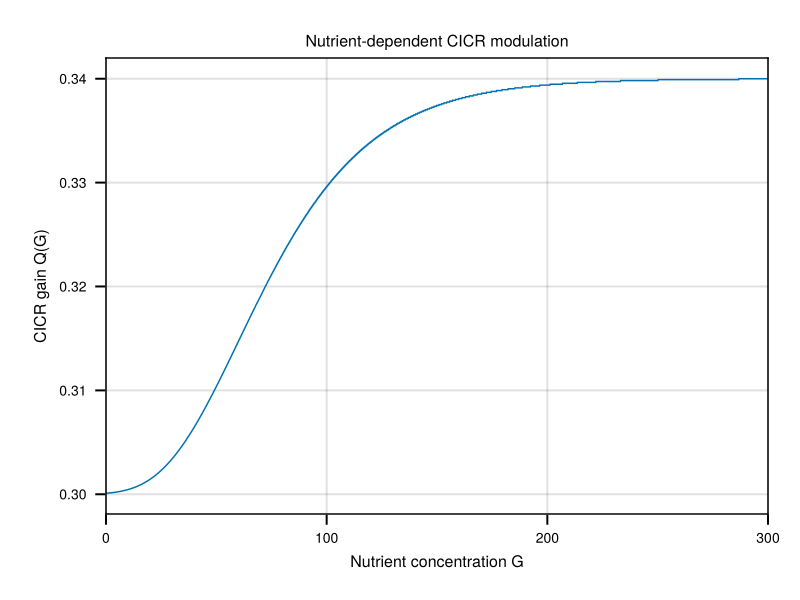

Q at low food: 0.3000942470238735
Q at high food: 0.33999999999999997


In [6]:
## 2.1c Nutrient to baseline flow coupling Q(G)

# This sigmoidal function maps nutrient concentration G to the CICR gain parameter Q.
# Biologically: higher nutrient → slightly stronger calcium oscillations (but never turns off).
# The function keeps Q in a narrow range [q_bar, q_bar + Θ₁] to maintain oscillatory dynamics.

const q_bar::Float64 = 0.3  # Baseline CICR gain (low nutrient) [BANDIT PARAM]
const Q::Float64 = q_bar     # Initial value (will be spatially varying)
const Θ₁::Float64 = 0.04     # Maximum increase above q_bar
const Θ₂::Float64 = 3e-2     # Sensitivity to nutrient changes
const Θ₃::Float64 = 60.0     # Nutrient level for half-maximal response
const Ξ::Float64 = 1e-13     # Asymmetry/sharpness parameter

# Smooth sigmoidal mapping from nutrient level G to baseline flow Q(G)
g5(x) = q_bar + Θ₁/(1 + Ξ*exp.(-Θ₂*(x-Θ₃)))^(1/Ξ)

# Visualize the nutrient response curve
g = 0:0.1:300
f_g_2 = q_bar .+ Θ₁./(1 .+ Ξ*exp.(-Θ₂*(g.-Θ₃))).^(1/Ξ)

fig_g5 = Figure(size=(400, 300))
ax_g5 = Axis(fig_g5[1, 1], 
             xlabel="Nutrient concentration G", 
             ylabel="CICR gain Q(G)",
             title="Nutrient-dependent CICR modulation")
lines!(ax_g5, g, f_g_2)
xlims!(ax_g5, 0, 300)
display(fig_g5)

println("Q at low food: $(g5(0.0))")
println("Q at high food: $(g5(300.0))")

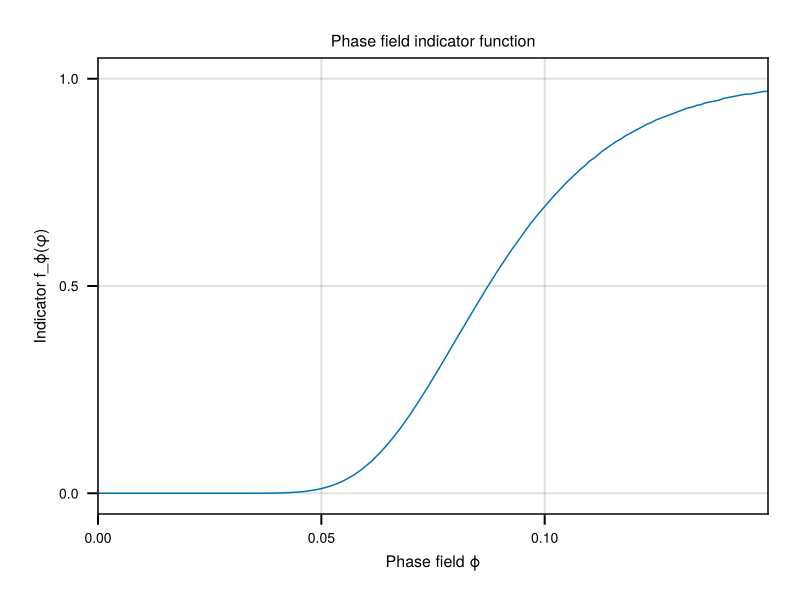

CairoMakie.Screen{IMAGE}


In [7]:
## 2.1d Parameters for phase field indicator function f_ϕ(φ)

# This function provides a smooth indicator of whether a location is inside (φ≈1) or outside (φ≈0) the cell.
# Used to restrict biochemical dynamics to the cell interior and enable smooth transitions at the boundary.

const ϕ_bar::Float64 = 0.0   # Exterior value (φ = 0)
const 𝚶₁::Float64 = 1.0      # Interior value (φ = 1)
const 𝚶₂::Float64 = 50.0     # Steepness of transition
const 𝚶₃::Float64 = 0.08     # Threshold for half-activation
const Π::Float64 = 1e-13     # Asymmetry parameter

# Visualize the phase field indicator function
ϕ_dom = 0:0.001:1
f_ϕ_curve = ϕ_bar .+ 𝚶₁./(1 .+ Π*exp.(-𝚶₂*(ϕ_dom.-𝚶₃))).^(1/Π)

fig_fphi = Figure(size=(400, 300))
ax_fphi = Axis(fig_fphi[1, 1], 
               xlabel="Phase field ϕ", 
               ylabel="Indicator f_ϕ(φ)",
               title="Phase field indicator function")
lines!(ax_fphi, ϕ_dom, f_ϕ_curve)
xlims!(ax_fphi, 0, 0.15)
display(fig_fphi)

In [8]:
## 2.2a Spatial and temporal discretization parameters

# Define the physical dimensions of the simulation domain
const Lx = 1.0   # mm (length)
const Ly = 0.1   # mm (width)

# Define the dimensions of the spatial grid
const Nx = 300
const Ny = 30

# Grid spacing
const dx::Float64 = Lx / Nx
const dy::Float64 = Ly / Ny
const dt::Float64 = 0.1

# Coordinate arrays
x_dom = range(0, stop=Lx, length=Nx)
y_dom = range(0, stop=Ly, length=Ny)

println("Bandit domain: $Lx mm × $Ly mm")
println("Grid: $Nx × $Ny (dx=$dx mm, dy=$dy mm)")
println("Time step: $dt s")

# Preallocate GPU arrays for simulation functions and derivatives
const Myϕ = CuArray(zeros(Float64, Ny, Nx));
const ϕMx = CuArray(zeros(Float64, Ny, Nx));
const Myc = CuArray(zeros(Float64, Ny, Nx));
const cMx = CuArray(zeros(Float64, Ny, Nx));
const Myh = CuArray(zeros(Float64, Ny, Nx));
const hMx = CuArray(zeros(Float64, Ny, Nx));
const Tyϕ = CuArray(zeros(Float64, Ny, Nx));
const ϕTx = CuArray(zeros(Float64, Ny, Nx));
const Dϕ = CuArray(zeros(Float64, Ny, Nx));
const Dc = CuArray(zeros(Float64, Ny, Nx));
const Dh = CuArray(zeros(Float64, Ny, Nx));
const gprime_ϕ = CuArray(zeros(Float64, Ny, Nx));
const f_c = CuArray(zeros(Float64, Ny, Nx));
const f_g = CuArray(zeros(Float64, Ny, Nx));
const f_ϕ = CuArray(zeros(Float64, Ny, Nx));
const f_ϕ_c = CuArray(zeros(Float64, Ny, Nx));
const abs_grad_ϕ = CuArray(zeros(Float64, Ny, Nx));
const V₀ = CuArray(zeros(Float64, 1));
const A₀ = CuArray(zeros(Float64, 1));

println("✓ GPU arrays allocated ($Ny × $Nx)")

Bandit domain: 1.0 mm × 0.1 mm
Grid: 300 × 30 (dx=0.0033333333333333335 mm, dy=0.0033333333333333335 mm)
Time step: 0.1 s
✓ GPU arrays allocated (30 × 300)


In [9]:
## 2.2b Discrete operators

# 1D finite-difference operators (assembled as tridiagonal matrices).
# Mx, My: second-derivative (central) stencils scaled by 1/dx^2 and 1/dy^2.
#       These produce the Laplacian when applied along each coordinate.
# Tx, Ty: central-difference first-derivative stencils (entries [-1,0,1]).
#       Note: these are defined without the 1/(2*dx) factor — the code applies that scaling
#       later where needed (see uses of abs_grad_ϕ and the (1/(2*dx)) factor in dϕ).
#
# Boundary treatment:
# We enforce reflective (Neumann / mirrored) boundary conditions by adjusting the
# corner/off-diagonal entries of the tridiagonals. Those modifications emulate
# mirrored ghost points so that the discrete derivative / Laplacian has zero normal flux.
#
# After building the CPU tridiagonals we convert them to CuArray for GPU matmul.

# Second derivative operators (Laplacian)
Mx = (1/dx^2) * Tridiagonal([1.0 for i in 1:Nx-1], [-2.0 for i in 1:Nx], [1.0 for i in 1:Nx-1])
My = (1/dy^2) * Tridiagonal([1.0 for i in 1:Ny-1], [-2.0 for i in 1:Ny], [1.0 for i in 1:Ny-1])

# Reflective / mirrored adjustments (different placements for x and y tridiagonals)
Mx[2,1] = 2.0   # left boundary mirror for x-operator
Mx[end-1,end] = 2.0   # right boundary mirror for x-operator
My[1,2] = 2.0   # top boundary mirror for y-operator
My[end,end-1] = 2.0   # bottom boundary mirror for y-operator

# First derivative operators (gradient)
Tx = Tridiagonal([-1.0 for i in 1:Nx-1], [0.0 for i in 1:Nx], [1.0 for i in 1:Nx-1])
Ty = Tridiagonal([-1.0 for i in 1:Ny-1], [0.0 for i in 1:Ny], [1.0 for i in 1:Ny-1])

# Same reflective adjustments for gradient operators
Tx[2,1] = 2.0
Tx[end-1,end] = 2.0
Ty[1,2] = 2.0
Ty[end,end-1] = 2.0

# GPU copies for use with mul!(out, A, X) inside the PDE function
const gMx = CuArray(Float64.(Mx));
const gMy = CuArray(Float64.(My));
const gTx = CuArray(Float64.(Tx));
const gTy = CuArray(Float64.(Ty));

println("✓ Finite difference operators created")

✓ Finite difference operators created


## 3. PDE model


In [10]:
# 3.1 Phase field PDE (deterministic part + noise)

function phasefieldpde!(du,u,p,t)
    # Unpack parameters
    @unpack Q, P, L, D, δ, A, B, K, C, k₁₊, τ, γ, ϵ, β, α, A₀, θ₁, θ₂, θ₃, ξ, k₁, k₂, P₀, k₄, Θ₁, Θ₂, Θ₃, Ξ, k₅, k₆, k₇, k₈, 𝚶₁, 𝚶₂, 𝚶₃, Π = p;
    
    # Fields
    ϕ = @view u[:,:,1];  # Phase field
    c = @view u[:,:,2];  # Calcium
    ω = @view u[:,:,3];  # Memory
    h = @view u[:,:,4];  # Thickness

    # Time derivatives
    dϕ = @view du[:,:,1];
    dc = @view du[:,:,2];
    dω = @view du[:,:,3];
    dh = @view du[:,:,4];

    # Compute spatial derivatives using finite difference operators
    mul!(Myϕ, gMy, ϕ)
    mul!(ϕMx, ϕ, gMx)
    mul!(Myc, gMy, c)
    mul!(cMx, c, gMx)
    mul!(Tyϕ, gTy, ϕ)
    mul!(ϕTx, ϕ, gTx)
        
    # Gradient magnitude and Laplacians
    @. abs_grad_ϕ = sqrt(Tyϕ^2 + ϕTx^2);
    @. Dϕ = (Myϕ + ϕMx);
    @. Dc = (Myc + cMx);
    
    # Indicator functions
    @. f_c = 1 - θ₁/(1 + ξ*exp.(-θ₂*(c-θ₃)))^(1/ξ)
    @. f_ϕ = 𝚶₁/(1 + Π*exp.(-𝚶₂*(ϕ-𝚶₃)))^(1/Π)
    @. f_ϕ_c = f_ϕ .* f_c;

    # Volume constraint
    ∱ϕ = sum(f_ϕ .* h .* dx * dy);
    @. gprime_ϕ = (72*ϕ^3 - 108*ϕ^2 + 36*ϕ);
   
    # Phase field equation
    @. dϕ = f_c .*(γ/τ)*((Dϕ - gprime_ϕ/ϵ^2)) - (β/τ)*(1/(2*dx))*(∱ϕ - V₀)* abs_grad_ϕ - (α/τ)*(1/(2*dx))*f_c.*abs_grad_ϕ;
    
    # Calcium equation
    @. dc = -f_ϕ .*P*(c^2/(c^2+B^2)) + f_ϕ .*(L + Q.*(c^2/(c^2 +A^2))*ω)*(C-c)*(1+δ) + f_ϕ .*D*Dc - k₄*c;
    
    # Memory equation
    @. dω = K*k₁₊*(1 - ω) - k₁₊*ω*c;
    
    # Thickness equation
    @. dh = - f_ϕ_c * k₅ .* h - f_ϕ .*k₆*(∱ϕ - V₀) - k₈*h;
end

# 3.2 Stochastic noise function
function phasefieldpdenoise!(du,u,p,t)
    ϕ = @view u[:,:,1];
    c = @view u[:,:,2];
    ω = @view u[:,:,3];
    h = @view u[:,:,4];
    dϕ = @view du[:,:,1];
    dc = @view du[:,:,2];
    dω = @view du[:,:,3];
    dh = @view du[:,:,4];
    
    @. f_ϕ = 𝚶₁/(1 + Π*exp.(-𝚶₂*(ϕ-𝚶₃)))^(1/Π)
    @. dϕ = f_ϕ*3e-1;
    @. dc = f_ϕ*2e-8;
    @. dω = 0.0;
end

println("✓ PDE functions defined")

✓ PDE functions defined


## 4. Food generation functions

In [11]:
# 4.1 Food landscape generation functions

"""
    generate_food_seq(lf, rf, Nx; distribution="even", seed=nothing, spacing=7)

Generate food source positions distributed across left and right halves of channel.
**CRITICAL**: Following Reed et al. 2016 experimental protocol, the FIRST site on each arm
is always anchored immediately adjacent to the initial slime mold position to ensure
exploration begins on both arms. Remaining sites are distributed according to pattern.

Returns sorted array of x-positions in grid units.

# Arguments
- `lf`: Number of food sources on left half (must be ≥1)
- `rf`: Number of food sources on right half (must be ≥1)
- `Nx`: Grid size in x-direction
- `distribution`: "even" or "random"
- `seed`: Random seed for reproducibility (optional, default: nothing)
- `spacing`: Minimum grid spacing between candidate center positions for random distribution (default: 7 grid points)
             Each site is 5 grid points wide, so spacing=7 ensures sites never overlap + 2-point gap between boundaries.
"""
function generate_food_seq(lf::Int, rf::Int, Nx::Int; distribution::String="even", seed::Union{Int, Nothing}=nothing, spacing::Int=7)
    n_half = floor(Int, Nx/2)
    
    # ANCHORED SITES: Always place first food site immediately adjacent to initial position
    # Initial slime mold spans n_half-10 to n_half+10 (positions 140 to 160 for Nx=300)
    # Anchored sites: left at n_half-15, right at n_half+15 (positions 135 and 165)
    left_anchor = n_half - 15
    right_anchor = n_half + 15
    
    if distribution == "random"
        # Set random seed if provided for reproducibility
        if seed !== nothing
            Random.seed!(seed)
        end
        
        # RANDOM distribution: anchor + random placement for remaining sites
        step_size = spacing
        
        # Create candidate pools EXCLUDING the anchor positions (reserve those)
        # Left candidates: from position 5 to (anchor - spacing), excluding anchor
        # Right candidates: from (anchor + spacing) to Nx-4, excluding anchor
        l_seq_tot = collect(5:step_size:left_anchor-spacing)
        r_seq_tot = collect(right_anchor+spacing:step_size:Nx-4)
        
        # Sample REMAINING sites (lf-1 on left, rf-1 on right)
        n_sample_l = min(lf-1, length(l_seq_tot))
        n_sample_r = min(rf-1, length(r_seq_tot))
        
        l_seq_extra = length(l_seq_tot) > 0 && n_sample_l > 0 ? sample(l_seq_tot, n_sample_l, replace=false) : Int[]
        r_seq_extra = length(r_seq_tot) > 0 && n_sample_r > 0 ? sample(r_seq_tot, n_sample_r, replace=false) : Int[]
        
        # Combine anchored + extra sites
        l_seq = [left_anchor; l_seq_extra]
        r_seq = [right_anchor; r_seq_extra]
        
        tot_seq = floor.(Int, [l_seq; r_seq;])
    else
        # EVEN distribution: anchor + evenly-spaced placement for remaining sites
        if lf == 1
            l_seq = [left_anchor]
        else
            # Distribute remaining (lf-1) sites evenly from left_anchor to edge
            dl = (left_anchor - 5) / (lf - 1)
            l_seq = [left_anchor:-dl:5;]
        end
        
        if rf == 1
            r_seq = [right_anchor]
        else
            # Distribute remaining (rf-1) sites evenly from right_anchor to edge
            dr = (Nx - 4 - right_anchor) / (rf - 1)
            r_seq = [right_anchor:dr:Nx-4;]
        end
        
        tot_seq = floor.(Int, [l_seq; r_seq;])
    end
    
    return tot_seq
end

"""
    generate_food_seq_nonbinary(f_seq, G, lf, rf, fs, Nx, seed)

Build nonbinary landscape with graded rewards following experimental paper methodology:
1. At the SITE LEVEL (not grid level), assign reward weights to each food location
2. Anchored sites (adjacent to slime mold) ALWAYS remain fixed at weight 5 (never modified)
3. Other sites initialized at weight 1
4. Additional reward units randomly distributed ONLY across non-anchored sites, one increment at a time
5. Maximum per site: weight 8
6. Continue until left arm total = 20 and right arm total = 40 (2:1 ratio)
7. Only AFTER site-level bookkeeping, map weights to continuous grid G

**CRITICAL**: The anchored sites maintain identical weights (5) throughout to ensure the organism
encounters equal food strength when first exploring each arm. The 2:1 ratio is achieved by
allocating 15 units to non-anchor left sites and 35 units to non-anchor right sites.

This ensures the 2:1 ratio is enforced at the abstract site level, independent of
grid resolution, patch width, or concentration scaling factors.

Returns (G, site_weights) tuple for verification.

# Arguments
- `f_seq`: Sorted food position sequence (locations already selected)
- `G`: Nutrient concentration grid (zeros initially)
- `lf`: Number of left food sources
- `rf`: Number of right food sources
- `fs`: Base food strength (reference concentration for mapping)
- `Nx`: Grid size in x-direction (default: 300)
- `seed`: Random seed for reproducible weight distribution (optional)
"""
function generate_food_seq_nonbinary(f_seq::Vector{Int}, G::Matrix{Float64}, lf::Int, rf::Int, fs::Float64, Nx::Int=300; seed::Union{Int, Nothing}=nothing)
    # Set random seed if provided for reproducibility
    if seed !== nothing
        Random.seed!(seed)
    end
    
    # STEP 1: Site-level reward bookkeeping (resolution-independent)
    # ---------------------------------------------------------------
    
    # Initialize site weights (abstract integer values 1-8)
    site_weights = Dict{Int, Int}()
    
    # Identify anchored sites by their POSITION VALUES (not array indices)
    # Anchored positions are always at n_half ± 15
    n_half = floor(Int, Nx/2)
    anchor_left_pos = n_half - 15   # Position 135 for Nx=300
    anchor_right_pos = n_half + 15  # Position 165 for Nx=300
    
    # Initialize ALL sites from f_seq first (ensures no missing keys later)
    for site_pos in f_seq
        site_weights[site_pos] = 1  # Start all at weight 1
    end
    
    # Then overwrite anchored sites to weight 5
    if anchor_left_pos in f_seq
        site_weights[anchor_left_pos] = 5
    else
        @warn "Left anchor position $anchor_left_pos not found in f_seq"
    end
    
    if anchor_right_pos in f_seq
        site_weights[anchor_right_pos] = 5
    else
        @warn "Right anchor position $anchor_right_pos not found in f_seq"
    end
    
    # Separate left and right sites for totals calculation
    left_sites = [pos for pos in f_seq if pos < n_half]
    right_sites = [pos for pos in f_seq if pos >= n_half]
    
    # Identify non-anchored sites (these will be modified)
    non_anchor_left = [pos for pos in left_sites if pos != anchor_left_pos]
    non_anchor_right = [pos for pos in right_sites if pos != anchor_right_pos]
    
    # Helper functions to compute total weights per arm
    left_total() = sum(site_weights[pos] for pos in left_sites)
    right_total() = sum(site_weights[pos] for pos in right_sites)
    
    # STEP 2: Distribute weights to reach fixed totals
    # ------------------------------------------------
    # Target: left arm total = 20, right arm total = 40 (2:1 ratio)
    # Anchors contribute 5 each, so we need to distribute:
    #   - Left: 20 - 5 = 15 units among non-anchor sites (already have 1 each)
    #   - Right: 40 - 5 = 35 units among non-anchor sites (already have 1 each)
    # Maximum weight per site: 8
    
    max_weight = 8
    target_left_total = 20
    target_right_total = 40
    max_iterations = 10000
    
    # Distribute weight to LEFT arm
    iteration = 0
    while left_total() < target_left_total && iteration < max_iterations
        iteration += 1
        
        # Find eligible sites (non-anchors with weight < max_weight)
        eligible_left = [pos for pos in non_anchor_left if site_weights[pos] < max_weight]
        
        if !isempty(eligible_left)
            site = rand(eligible_left)
            site_weights[site] += 1
        else
            @warn "Cannot reach left target of $target_left_total with max weight $max_weight)"
            break
        end
    end
    
    # Distribute weight to RIGHT arm
    iteration = 0
    while right_total() < target_right_total && iteration < max_iterations
        iteration += 1
        
        # Find eligible sites (non-anchors with weight < max_weight)
        eligible_right = [pos for pos in non_anchor_right if site_weights[pos] < max_weight]
        
        if !isempty(eligible_right)
            site = rand(eligible_right)
            site_weights[site] += 1
        else
            @warn "Cannot reach right target of $target_right_total with max weight $max_weight)"
            break
        end
    end
    
    # Verify final totals
    final_left = left_total()
    final_right = right_total()
    if final_left != target_left_total || final_right != target_right_total
        @warn "Target totals not reached: left=$final_left (target $target_left_total), right=$final_right (target $target_right_total)"
    end
    
    # STEP 3: Map site-level weights to continuous grid
    # --------------------------------------------------
    # To make total food amounts comparable to regular conditions where all sites = fs,
    # we need to scale up the weights so total food matches.
    # 
    # In regular conditions: each of (lf+rf) sites gets concentration fs
    # In nonbinary: we have varying weights, average weight determines scaling
    #
    # Strategy: Scale so that if all sites were at their current average weight,
    # the total would match the regular condition total.
    
    total_weight = sum(values(site_weights))
    n_sites = length(site_weights)
    avg_weight = total_weight / n_sites
    
    # Regular condition would have: n_sites × fs total food
    # Nonbinary with current weights: n_sites × avg_weight × (fs/8) = total_weight × (fs/8)
    # To match regular: we want total_weight × scale = n_sites × fs
    # Therefore: scale = (n_sites × fs) / total_weight = fs / avg_weight
    
    # But we also need to preserve the relative weights (1-8 scale)
    # So we use: weight_to_concentration = fs / avg_weight, but cap at reasonable values
    # Actually simpler: just scale so weight=8 corresponds to more than fs
    
    # Better approach: make the average weight map to fs
    # This ensures total food amount is comparable
    weight_to_concentration = fs / avg_weight
    
    for (site_pos, weight) in site_weights
        concentration = weight * weight_to_concentration
        G[:, site_pos-2:site_pos+2] .= concentration
    end
    
    # Apply Gaussian smoothing for continuous PDE model
    G = ImageFiltering.imfilter(G, ImageFiltering.Kernel.gaussian(1))
    
    return (G, site_weights)
end

println("✓ Food generation functions defined")
     

✓ Food generation functions defined


VISUALIZING INITIAL FOOD SETUPS
  1 vs 1 (even): Left=1 sites, Right=1 sites
  16 vs 16 (even): Left=16 sites, Right=16 sites
  8 vs 8 (even): Left=8 sites, Right=8 sites
  1 vs 8 (even): Left=1 sites, Right=8 sites
  4 vs 8 (even): Left=4 sites, Right=8 sites
  8 vs 16 (even): Left=8 sites, Right=16 sites
  11 vs 16 (even): Left=11 sites, Right=16 sites
  8 vs 8 (random): Left=8 sites, Right=8 sites
  4 vs 8 (random): Left=4 sites, Right=8 sites
  8 vs 16 (random): Left=8 sites, Right=16 sites
  11 vs 16 (random): Left=11 sites, Right=16 sites
  8 vs 8 (nonbinary): Left=8 sites (Σwt=20), Right=8 sites (Σwt=40), Ratio=2.0
Food setups figure: 3.99 × 8.78 cm  (113 × 249 px)

✓ Saved: figures\all_food_setups_Q.svg/.png
✓ Saved: figures\all_food_setups_Q_colorbar.svg/.png


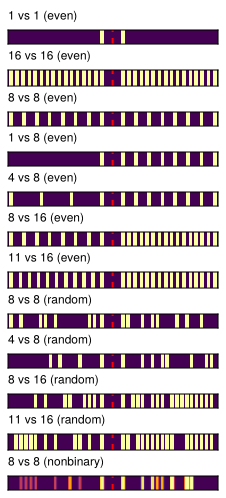

In [12]:
# 4.2 Visualize initial food setups for all experimental conditions

println("="^60)
println("VISUALIZING INITIAL FOOD SETUPS")
println("="^60)

local_experimental_conditions = [
    (1,  1,  "even",     "1 vs 1 (even)"),
    (16, 16, "even",     "16 vs 16 (even)"),
    (8,  8,  "even",     "8 vs 8 (even)"),
    (1,  8,  "even",     "1 vs 8 (even)"),
    (4,  8,  "even",     "4 vs 8 (even)"),
    (8,  16, "even",     "8 vs 16 (even)"),
    (11, 16, "even",     "11 vs 16 (even)"),
    (8,  8,  "random",   "8 vs 8 (random)"),
    (4,  8,  "random",   "4 vs 8 (random)"),
    (8,  16, "random",   "8 vs 16 (random)"),
    (11, 16, "random",   "11 vs 16 (random)"),
    (8,  8,  "nonbinary","8 vs 8 (nonbinary)")
]

local_fs_experiment = 300.0
n_conditions = length(local_experimental_conditions)

panel_w = cm_to_px(4.0)
total_h = cm_to_px(3.06)
panel_h = total_h / n_conditions

fig_setups = Figure(size=(Int(round(panel_w)), Int(round(total_h))), figure_padding=(4, 4, 4, 4))

last_hm = nothing

for (idx, (lf, rf, distribution, label)) in enumerate(local_experimental_conditions)
    row = idx

    G_viz = zeros(Float64, Ny, Nx)
    site_weights = nothing
    f_seq_stored = nothing

    if distribution == "nonbinary"
        f_seq = sort(generate_food_seq(lf, rf, Nx; distribution="random", seed=idx*10000))
        f_seq_stored = f_seq
        G_viz, site_weights = generate_food_seq_nonbinary(f_seq, G_viz, lf, rf, local_fs_experiment, Nx; seed=idx*2000)
        # Rescale for visualization: map nonzero values to full [0, fs] range
        # so graded weights span the full colormap (purple=low, yellow=high)
        nonzero_mask = G_viz .> 0
        if any(nonzero_mask)
            g_min = minimum(G_viz[nonzero_mask])
            g_max = maximum(G_viz[nonzero_mask])
            G_viz_display = zeros(Float64, size(G_viz))
            if g_max > g_min
                G_viz_display[nonzero_mask] .= (G_viz[nonzero_mask] .- g_min) ./ (g_max - g_min) .* local_fs_experiment
            else
                G_viz_display[nonzero_mask] .= local_fs_experiment
            end
            Q_viz = g5.(G_viz_display)
        else
            Q_viz = g5.(G_viz)
        end
    elseif distribution == "random"
        f_seq = sort(generate_food_seq(lf, rf, Nx; distribution="random", seed=idx*10000))
        for j in f_seq
            G_viz[:,j-2:j+2] .= local_fs_experiment
        end
        Q_viz = g5.(G_viz)
    else
        f_seq = sort(generate_food_seq(lf, rf, Nx; distribution="even"))
        for j in f_seq
            G_viz[:,j-2:j+2] .= local_fs_experiment
        end
        Q_viz = g5.(G_viz)
    end

    ax = Axis(fig_setups[row, 1],
             title              = label,
             titlesize          = 6,
             titlealign         = :left,
             yticksvisible      = false,
             yticklabelsvisible = false,
             xticksvisible      = false,
             xticklabelsvisible = false,
             xlabelvisible      = false,
             leftspinevisible   = true,
             rightspinevisible  = true,
             topspinevisible    = true,
             bottomspinevisible = true,
             spinewidth         = 0.5,
             leftspinecolor     = :black,
             rightspinecolor    = :black,
             topspinecolor      = :black,
             bottomspinecolor   = :black)

    last_hm = heatmap!(ax, 1:Nx, 1:Ny, Q_viz', colormap=nutrient_cmap, rasterize=10)
    vlines!(ax, [Nx/2], color=:red, linestyle=:dash, linewidth=1)

    if distribution == "nonbinary" && site_weights !== nothing
        n_half_viz = div(Nx, 2)
        left_sites_viz  = [pos for pos in f_seq_stored if pos <  n_half_viz]
        right_sites_viz = [pos for pos in f_seq_stored if pos >= n_half_viz]
        left_weight_total  = sum(site_weights[pos] for pos in left_sites_viz)
        right_weight_total = sum(site_weights[pos] for pos in right_sites_viz)
        ratio = right_weight_total / left_weight_total
        println("  $label: Left=$(length(left_sites_viz)) sites (Σwt=$left_weight_total), Right=$(length(right_sites_viz)) sites (Σwt=$right_weight_total), Ratio=$(round(ratio,digits=3))")
    else
        println("  $label: Left=$lf sites, Right=$rf sites")
    end
end

for i in 1:n_conditions
    rowsize!(fig_setups.layout, i, Fixed(panel_h))
end

rowgap!(fig_setups.layout, 2)
resize_to_layout!(fig_setups)
sz = fig_setups.scene.viewport[].widths
println("Food setups figure: $(round(sz[1]/28.3465, digits=2)) × $(round(sz[2]/28.3465, digits=2)) cm  ($(sz[1]) × $(sz[2]) px)")
display(fig_setups)

save_svg(fig_setups, "all_food_setups_Q")
CairoMakie.save(joinpath(FIGDIR, "all_food_setups_Q.png"), fig_setups, px_per_unit=2)
println("\n✓ Saved: $(joinpath(FIGDIR, "all_food_setups_Q.svg/.png"))")

# Save standalone colorbar
fig_cbar = Figure(size=(Int(round(cm_to_px(1.0))), Int(round(cm_to_px(4.0)))), figure_padding=4)
Colorbar(fig_cbar[1, 1], last_hm, label="Q", labelsize=7, ticklabelsize=6, vertical=true)
resize_to_layout!(fig_cbar)
save_svg(fig_cbar, "all_food_setups_Q_colorbar")
CairoMakie.save(joinpath(FIGDIR, "all_food_setups_Q_colorbar.png"), fig_cbar, px_per_unit=2)
println("✓ Saved: $(joinpath(FIGDIR, "all_food_setups_Q_colorbar.svg/.png"))")
println("="^60)


## 5. Experimental Protocol

This section implements all experimental conditions reported in the paper (N=30 replicates per treatment).

**Baseline conditions (equal rewards):** 16ev16e, 1ev1e, 8ev8e 
**Reward difference but evenly distributeds:** 4ev8e 8ev16e, 11ev16e  
**Irregular distributions:**  8rv8r, 4rv8r, 8rv16r  
**Non-binary rewards:** 8v8_nonbinary (graded rewards)

Nomenclature: "LvR" = L food sources on left, R on right; "e" = evenly distributed; "r" = randomly distributed 

In [15]:
# 5.1 Configuration for all experiments

# Number of replicates per treatment (as in the biological experiments by Reed et al. 2016)
n_reps_experiment = 30

# Simulation parameters
fs_experiment = 300.0      # Food strength for experiments
tf_experiment = 1000.0     # Simulation time (seconds)
savetimes_experiment = 0.0:1.0:tf_experiment

# Define all experimental conditions
# Format: (left_count, right_count, distribution_type, label)
# distribution_type: "even" or "random"
experimental_conditions = [
    # Baseline (equal rewards, evenly distributed)
    (1, 1, "even", "1ev1e"),
    (16, 16, "even", "16ev16e"),
    (8, 8, "even", "8ev8e"),
    
    # Sensitivity to reward differences (evenly distributed)
    (1, 8, "even", "1ev8e"),
    (4, 8, "even", "4ev8e"),
    (8, 16, "even", "8ev16e"),
    (11, 16, "even", "11ev16e"),
    
    # Random distributions
    (8, 8, "random", "8rv8r"),
    (4, 8, "random", "4rv8r"),
    (8, 16, "random", "8rv16r"),
    (11, 16, "random", "11rv16r"),
    
    # Non-binary (handled separately)
    (8, 8, "nonbinary", "8v8_nonbinary")
]

println("=== Experimental Protocol ===")
println("Replicates per treatment: $n_reps_experiment")
println("Total treatments: $(length(experimental_conditions))")
println("Total simulations: $(length(experimental_conditions) * n_reps_experiment)")
println("Simulation time per replicate: $tf_experiment s")
println("\nTreatments:")
for (lf, rf, dist, label) in experimental_conditions
    println("  $label: $lf vs $rf ($dist)")
end

=== Experimental Protocol ===
Replicates per treatment: 30
Total treatments: 12
Total simulations: 360
Simulation time per replicate: 1000.0 s

Treatments:
  1ev1e: 1 vs 1 (even)
  16ev16e: 16 vs 16 (even)
  8ev8e: 8 vs 8 (even)
  1ev8e: 1 vs 8 (even)
  4ev8e: 4 vs 8 (even)
  8ev16e: 8 vs 16 (even)
  11ev16e: 11 vs 16 (even)
  8rv8r: 8 vs 8 (random)
  4rv8r: 4 vs 8 (random)
  8rv16r: 8 vs 16 (random)
  11rv16r: 11 vs 16 (random)
  8v8_nonbinary: 8 vs 8 (nonbinary)


In [ ]:
# 5.2 Helper function for creating fresh initial conditions

function create_initial_conditions_bandit()
    CUDA.allowscalar(true)
    
    # Phase field: horizontal strip at center
    ϕ₀ = zeros(Float64, Ny, Nx)
    n_half = floor(Int, Nx/2)
    
    for i in 1:Ny
        for j in 1:Nx
            if j > n_half-10 && j < n_half+10
                ϕ₀[i, j] = 1.0
            end
        end
    end
    
    # Thickness: calculate to match target volume
    h0 = 1.3*(Lx*Ly*h_bar)/sum(ϕ₀ .* dx * dy)
    
    # Calcium and memory: proportional to phase field
    c₀ = c_bar.*ϕ₀
    ω₀ = w_bar.*ϕ₀
    h₀ = h0.*ϕ₀
    
    # Set volume constraint (global V₀)
    V₀[1] = sum(ϕ₀ .* h₀ .* dx * dy)
    
    # Pack into 4D array
    u0 = zeros(Ny, Nx, 4)
    u0[:,:,1] = ϕ₀
    u0[:,:,2] = c₀
    u0[:,:,3] = ω₀
    u0[:,:,4] = h₀
    
    CUDA.allowscalar(false)
    return CuArray(Float64.(u0))
end

println("✓ Initial conditions helper defined")

In [ ]:
# 5.2.3 Run ALL experimental conditions (30 replicates each)
# Each replicate with random/nonbinary distribution gets a unique food layout

CUDA.allowscalar(false)

# Create main output directory
main_output_dir = "bandit_experiment_data"
if !isdir(main_output_dir)
    mkdir(main_output_dir)
end

println("="^60)
println("RUNNING ALL EXPERIMENTAL CONDITIONS")
println("Total treatments: $(length(experimental_conditions))")
println("Replicates per treatment: $n_reps_experiment")
println("NOTE: Random/nonbinary replicates get unique food layouts")
println("="^60)

for (treatment_idx, (lf, rf, distribution, label)) in enumerate(experimental_conditions)
    println("\n" * "="^60)
    println("TREATMENT: $label ($lf vs $rf, $distribution)")
    println("="^60)
    
    # Create output directory
    output_dir = joinpath(main_output_dir, label)
    if !isdir(output_dir)
        mkdir(output_dir)
    end
    
    # Run all 30 replicates - EACH WITH UNIQUE LAYOUT
    for rep = 1:n_reps_experiment
        println("\n--- Replicate $rep/$n_reps_experiment ---")
        
        # Set unique seed for random/nonbinary replicates
        replicate_seed = treatment_idx * 10000 + rep
        Random.seed!(replicate_seed)
        if distribution != "even"
            println("Replicate seed: $replicate_seed")
        end
        
        # Generate food landscape for this replicate
        G = zeros(Float64, Ny, Nx)
        
        if distribution == "nonbinary"
            # Nonbinary: randomly positioned sites with graded rewards
            f_seq = sort(generate_food_seq(lf, rf, Nx; distribution="random", seed=replicate_seed))
            G, site_weights = generate_food_seq_nonbinary(f_seq, G, lf, rf, fs_experiment, Nx; seed=replicate_seed)
            
            # Report site-level weights
            n_half_sim = div(Nx, 2)
            left_sites_sim = [pos for pos in f_seq if pos < n_half_sim]
            right_sites_sim = [pos for pos in f_seq if pos >= n_half_sim]
            left_weight_total = sum(site_weights[pos] for pos in left_sites_sim)
            right_weight_total = sum(site_weights[pos] for pos in right_sites_sim)
            ratio = right_weight_total / left_weight_total
            println("  Site weights: L=$left_weight_total, R=$right_weight_total (ratio=$(round(ratio,digits=3)))")
            
        elseif distribution == "random"
            # Random distribution with unique seed per replicate
            f_seq = sort(generate_food_seq(lf, rf, Nx; distribution="random", seed=replicate_seed))
            for j in f_seq
                G[:,j-2:j+2] .= fs_experiment
            end
            G = ImageFiltering.imfilter(G, ImageFiltering.Kernel.gaussian(1))
            println("  Food positions: $(f_seq)")
            
        else  # "even" distribution
            # Even distribution (same for all replicates)
            f_seq = sort(generate_food_seq(lf, rf, Nx; distribution="even"))
            for j in f_seq
                G[:,j-2:j+2] .= fs_experiment
            end
            G = ImageFiltering.imfilter(G, ImageFiltering.Kernel.gaussian(1))
            if rep == 1
                println("  Food positions (same for all replicates): $(f_seq)")
            end
        end
        
        # Save THIS replicate's food configuration
        CSV.write(joinpath(output_dir, "food_landscape_rep$(rep).csv"), DataFrame(G, :auto))
        if distribution != "even" || rep == 1
            CSV.write(joinpath(output_dir, "food_positions_rep$(rep).csv"), DataFrame(position=f_seq))
        end
        
        # Transform to Q
        Q₀ = CuArray(g5.(G))
        
        # Initial conditions
        u0 = create_initial_conditions_bandit()
        
        # Pack parameters
        p = (Q=Q₀, P=P, L=L, D=D, δ=δ, A=A, B=B, K=K, C=C, k₁₊=k₁₊, 
             τ=τ, γ=γ, ϵ=ϵ, β=β, α=α, A₀=V₀, 
             θ₁=θ₁, θ₂=θ₂, θ₃=θ₃, ξ=ξ, k₁=k₁, k₂=k₂, P₀=P₀, k₄=k₄, 
             Θ₁=Θ₁, Θ₂=Θ₂, Θ₃=Θ₃, Ξ=Ξ, k₅=k₅, k₆=k₆, k₇=k₇, k₈=k₈, ζ=ζ, 
             𝚶₁=𝚶₁, 𝚶₂=𝚶₂, 𝚶₃=𝚶₃, Π=Π)
        
        # Solve
        tspan = (0.0, tf_experiment)
        prob = SDEProblem(phasefieldpde!, phasefieldpdenoise!, u0, tspan, p)
        sol = solve(prob, saveat=savetimes_experiment)
        
        # Export thickness data (3 rows)
        CUDA.allowscalar(true)
        rows_to_export = [div(Ny, 3), div(Ny, 2), 2*div(Ny, 3)]
        n_rows_export = length(rows_to_export)
        
        v_df = zeros(length(sol.t), n_rows_export*Nx + 1)
        v_df[:,1] = sol.t
        
        for k = 1:length(sol.t)
            for (j, row) in enumerate(rows_to_export)
                v_df[k, (j-1)*Nx+2 : j*Nx+1] = sol.u[k][row, :, 4]
            end
        end
        
        # Save to CSV
        out_df = DataFrame(v_df, :auto)
        filename = joinpath(output_dir, "exp_$(rep).csv")
        CSV.write(filename, out_df)
        
        println("  Saved: $filename")
        CUDA.allowscalar(false)
    end
    
    println("\n✓ Completed $n_reps_experiment replicates for $label")
end

println("\n" * "="^60)
println("ALL EXPERIMENTS COMPLETE")
println("Total simulations: $(length(experimental_conditions) * n_reps_experiment)")
println("="^60)

## 6. Analysis of Saved Experiments

**Note:** If you already have experiment data saved in `bandit_experiment_data/`, you can skip running the simulation cells above and proceed directly to the visualization and analysis cells below. The analysis functions load data directly from CSV files as needed.

Here we perform the same type of analysis as in the Reed et al. (2016) paper.

Found 12 experiments to visualize...
  11e vs 16e (11ev16e): Left Q = 0.3187, Right Q = 0.3272
  11r vs 16r (11rv16r): Left Q = 0.319, Right Q = 0.3277
  16e vs 16e (16ev16e): Left Q = 0.3272, Right Q = 0.3272
  1 vs 1 (1v1): Left Q = 0.3018, Right Q = 0.3018
  1 vs 8e (1v8e): Left Q = 0.3018, Right Q = 0.3136
  4e vs 8e (4ev8e): Left Q = 0.3068, Right Q = 0.3136
  4r vs 8r (4rv8r): Left Q = 0.3068, Right Q = 0.3137
  8e vs 16e (8ev16e): Left Q = 0.3136, Right Q = 0.3272
  8e vs 8e (8ev8e): Left Q = 0.3136, Right Q = 0.3136
  8r vs 16r (8rv16r): Left Q = 0.3137, Right Q = 0.3278
  8r vs 8r (8rv8r): Left Q = 0.3136, Right Q = 0.3138
  8 vs 8 (nonbinary) (8rv8r_nonbinary): Left Q = 0.3055, Right Q = 0.311

✓ Q landscape visualization complete
  Cyan dashed line marks center (x=150)
  Q range: 0.3 to 0.33999999999999997
  Colorbar shown on first plot for scale reference


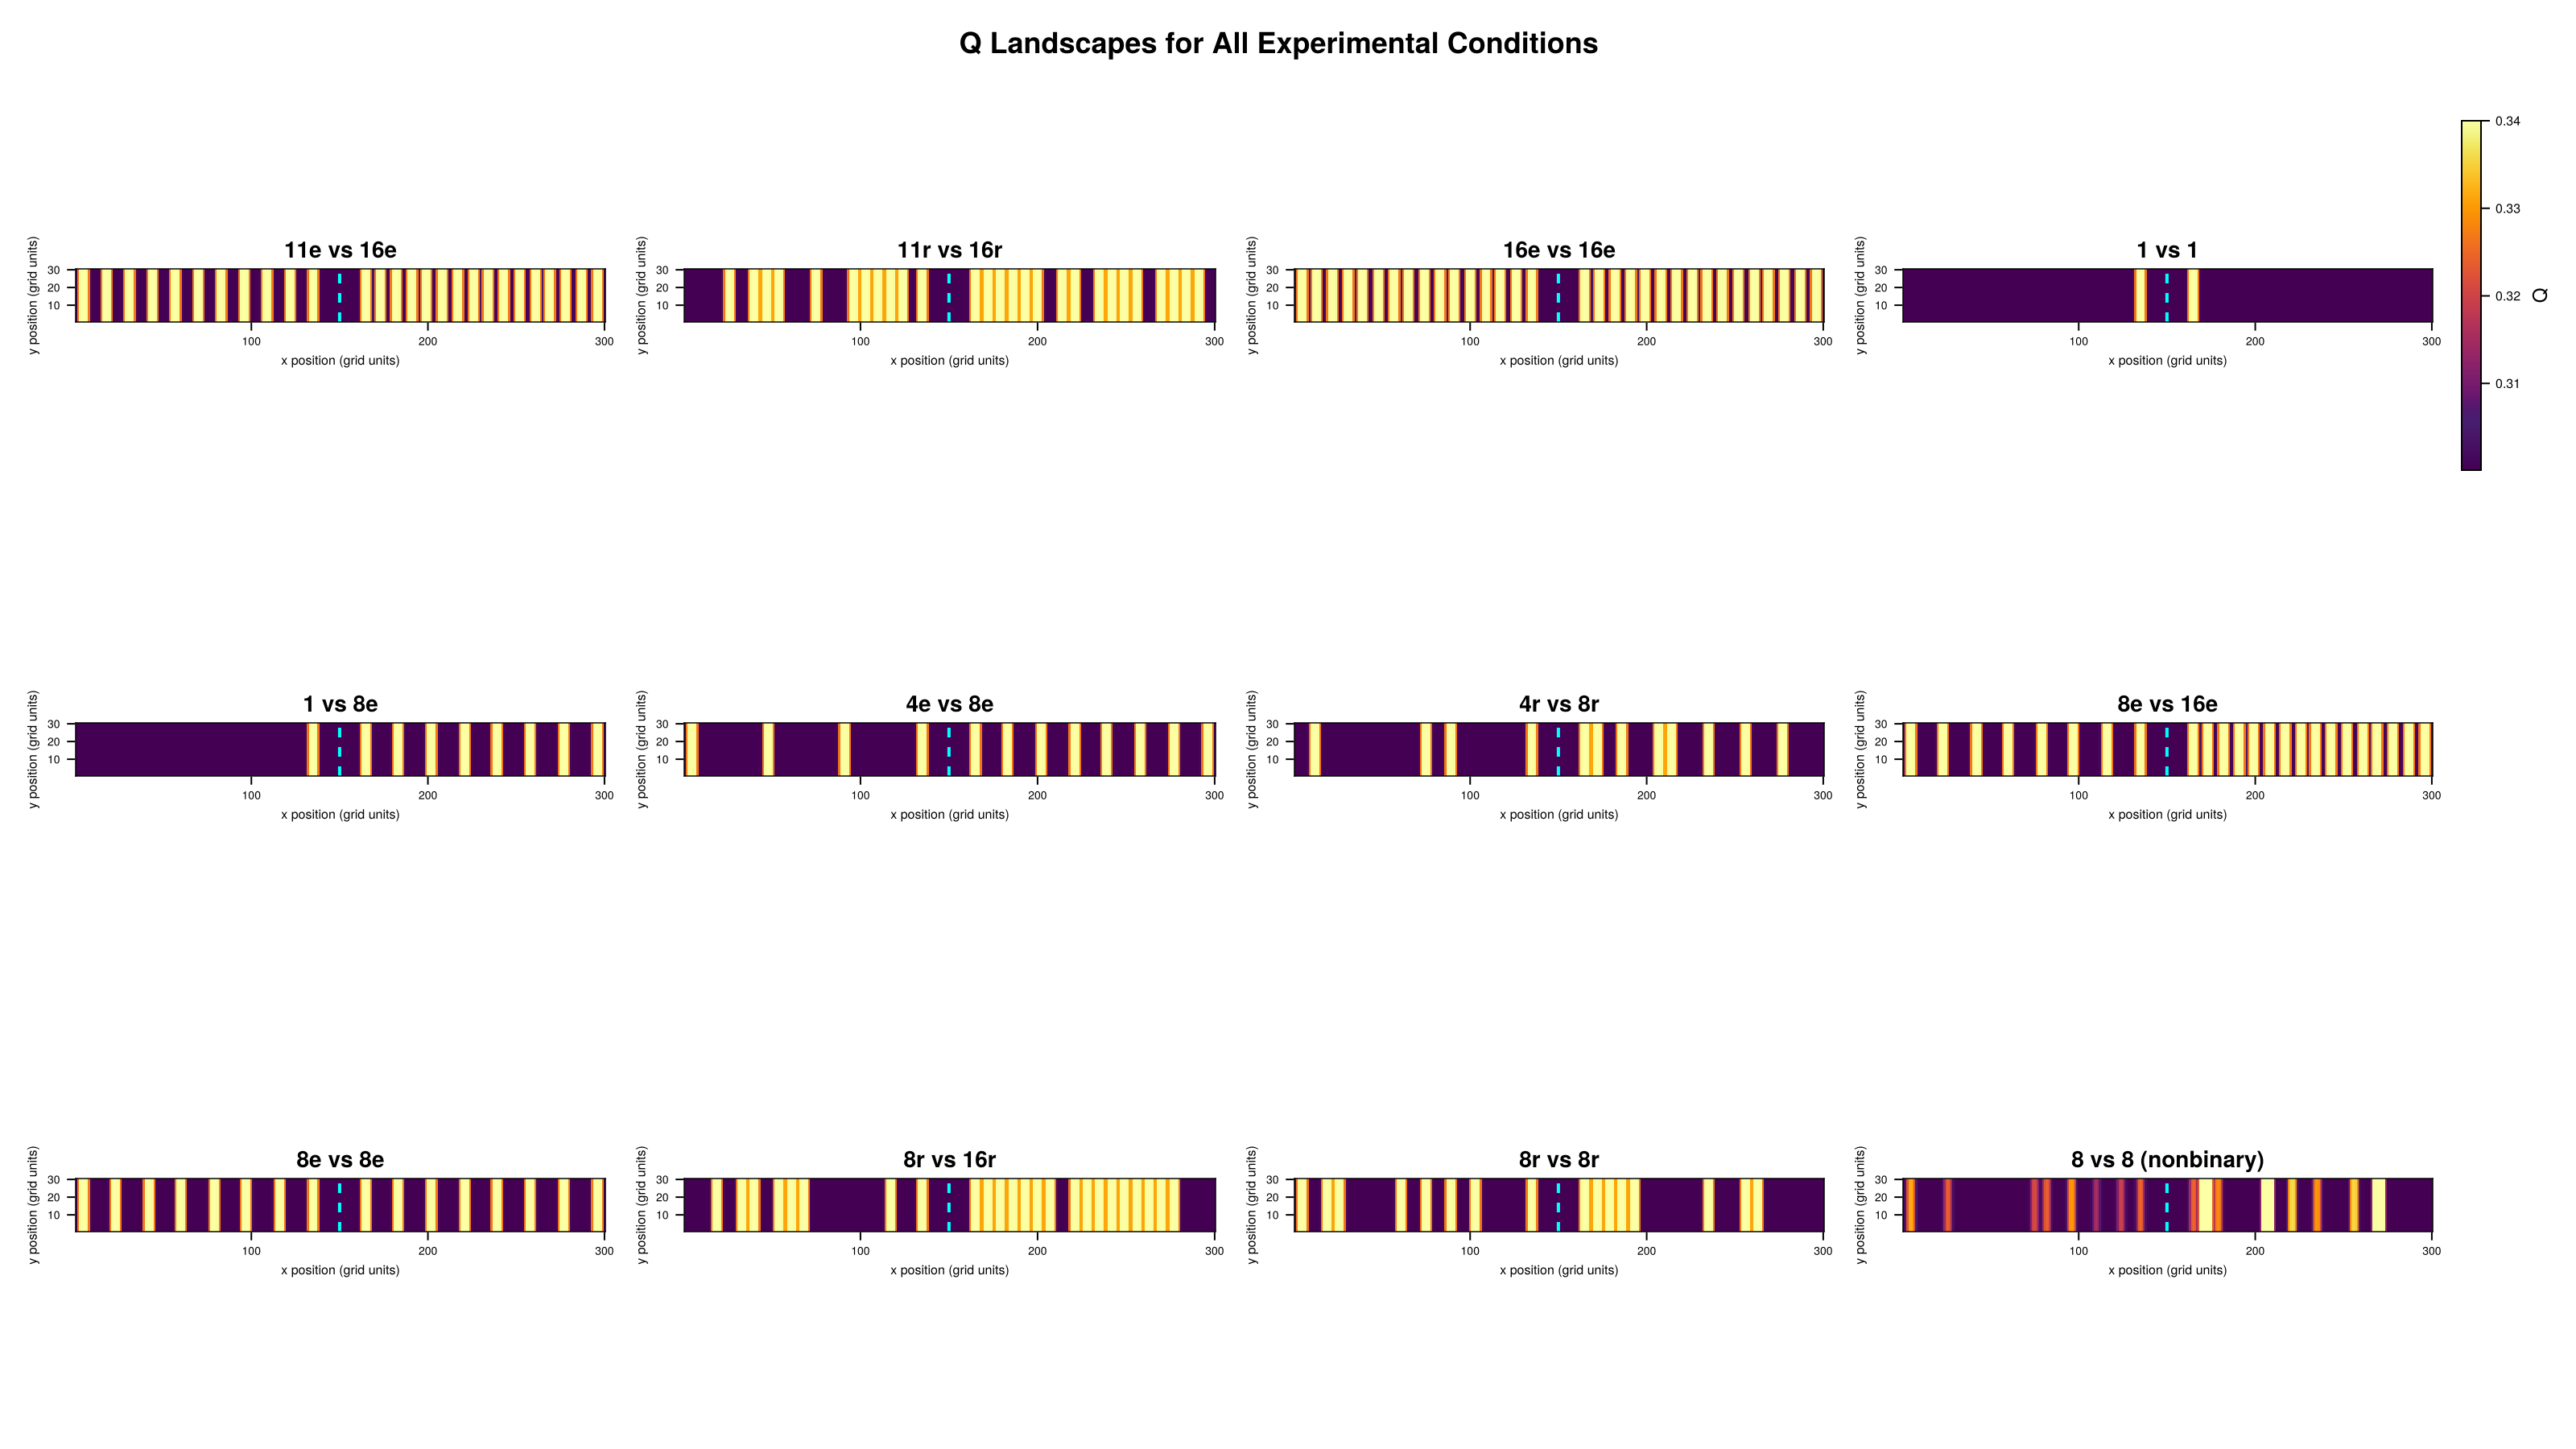

In [31]:
# 6.0 Visualize all food distributions (as Q values)
# This cell plots Q for each experimental condition, showing how nutrient landscapes
# map to CICR gain parameter (ranges from q_bar=0.3 to q_bar+Θ₁=0.34)

# Define experiment labels for plotting (maps folder name → display label)
experiment_labels = Dict(
    "1v1" => "1 vs 1",
    "16ev16e" => "16e vs 16e",
    "8ev8e" => "8e vs 8e",
    "1v8e" => "1 vs 8e",
    "4ev8e" => "4e vs 8e",
    "8ev16e" => "8e vs 16e",
    "11ev16e" => "11e vs 16e",
    "8rv8r" => "8r vs 8r",
    "4rv8r" => "4r vs 8r",
    "8rv16r" => "8r vs 16r",
    "11rv16r" => "11r vs 16r",
    "8rv8r_nonbinary" => "8 vs 8 (nonbinary)"
)

# Find all experiment directories from Bandit_experiments_cleaned
main_data_dir = joinpath(@__DIR__, "Bandit_experiments_cleaned")
all_folders = filter(d -> isdir(joinpath(main_data_dir, d)), readdir(main_data_dir))

# Sort folders to match the order in experimental_conditions
exp_labels_sorted = sort(all_folders)
n_experiments = length(exp_labels_sorted)

println("Found $n_experiments experiments to visualize...")

# Calculate grid layout (aim for roughly square layout)
n_cols = ceil(Int, sqrt(n_experiments))
n_rows = ceil(Int, n_experiments / n_cols)

# Create figure
fig_food = Figure(size=(400*n_cols, 300*n_rows))

for (idx, folder) in enumerate(exp_labels_sorted)
    # Get display label (use custom label if defined, otherwise use folder name)
    display_label = get(experiment_labels, folder, folder)
    # Read food landscape directly from CSV (with _1.3x suffix)
    exp_dir = joinpath(main_data_dir, folder * "_1.3x")
    exp_dir = joinpath(main_data_dir, folder)
    
    # All experiments in Bandit_experiments_cleaned use _rep1.csv naming
    food_landscape_file = joinpath(exp_dir, "food_landscape_rep1.csv")
    
    # Load as numeric matrix and convert to Q using g5 function
    food_landscape = Float64.(Matrix(CSV.read(food_landscape_file, DataFrame)))
    Q_landscape = g5.(food_landscape)  # Transform G → Q(G)
    
    # Calculate subplot position
    row = div(idx - 1, n_cols) + 1
    col = mod(idx - 1, n_cols) + 1
    
    # Create axis
    ax = Axis(fig_food[row, col],
             title = display_label,
             xlabel = "x position (grid units)",
             ylabel = "y position (grid units)",
             aspect = DataAspect(),
             titlesize = 14)
    
    # Plot Q landscape as heatmap (transpose for correct orientation)
    hm = heatmap!(ax, 1:size(Q_landscape, 2), 1:size(Q_landscape, 1), 
                  Q_landscape', colormap=nutrient_cmap)
    
    # Mark center line
    vlines!(ax, [size(Q_landscape, 2)/2], color=:cyan, linestyle=:dash, linewidth=2)
    
    # Add colorbar for first plot only (to show scale)
    if idx == 1
        Colorbar(fig_food[row, n_cols+1], hm, label="Q", labelsize=12)
    end
    
    # Print summary (using Q values)
    left_half = Q_landscape[:, 1:div(size(Q_landscape, 2), 2)]
    right_half = Q_landscape[:, div(size(Q_landscape, 2), 2)+1:end]
    left_mean = mean(left_half)
    right_mean = mean(right_half)
    println("  $display_label ($folder): Left Q = $(round(left_mean, digits=4)), Right Q = $(round(right_mean, digits=4))")
end

# Add overall title
Label(fig_food[0, :], "Q Landscapes for All Experimental Conditions", 
      fontsize=18, font=:bold)

display(fig_food)

println("\n✓ Q landscape visualization complete")
println("  Cyan dashed line marks center (x=$(div(Nx, 2)))")
println("  Q range: $(q_bar) to $(q_bar + Θ₁)")
println("  Colorbar shown on first plot for scale reference")

In [20]:
# 6.1a ANALYSIS: Compute exploration trajectories for all experiments

using CSV, DataFrames, Statistics, Distributions

# Define output directory
results_dir = joinpath(@__DIR__, "analysis_results")
isdir(results_dir) || mkdir(results_dir)

# Load experiment data
function load_experiment_data(exp_name::String)
    exp_dir = joinpath(@__DIR__, "Bandit_experiments_cleaned", exp_name)
    
    # All experiments in Bandit_experiments_cleaned use _rep1.csv naming
    food_pos_file = "food_positions_rep1.csv"
    food_landscape_file = "food_landscape_rep1.csv"
    
    food_pos = CSV.read(joinpath(exp_dir, food_pos_file), DataFrame)
    positions = vec(Matrix(food_pos))
    food_landscape = CSV.read(joinpath(exp_dir, food_landscape_file), DataFrame)
    rep_files = sort(filter(f -> startswith(f, "exp_") && endswith(f, ".csv"), readdir(exp_dir)))
    replicates = Dict()
    for file in rep_files
        rep_num = parse(Int, match(r"exp_(\d+)", file).captures[1])
        replicates[rep_num] = CSV.read(joinpath(exp_dir, file), DataFrame)
    end
    return (name=exp_name, positions=positions, food_landscape=food_landscape, 
            replicates=replicates, n_reps=length(replicates))
end

# Extract time series: x_left(t), x_right(t), f(t)=max(x_left,x_right)
function extract_timeseries(replicate_data, Nx::Int=300, Ny::Int=3; debug::Bool=false)
    midL = Nx ÷ 2          # Left half ends at index 150
    midR = midL + 1        # Right half starts at index 151
    n_timepoints = size(replicate_data, 1)
    times, x_lefts, x_rights = Float64[], Int[], Int[]
    
    for t in 1:n_timepoints
        # Extract row 3 directly - it's positions 601:900
        thickness_vec = Vector(replicate_data[t, 2:end])
        thickness_profile = thickness_vec[601:900]  # Row 3 only (300 X-positions)
        threshold = maximum(thickness_profile) * 0.01
        
        # Find furthest LEFT position (smallest X with thickness > threshold)
        left_region = thickness_profile[1:150]
        furthest_left = findfirst(left_region .> threshold)
        furthest_left = furthest_left === nothing ? 150 : furthest_left
        
        # Find furthest RIGHT position (largest X with thickness > threshold)
        right_region = thickness_profile[151:end]
        furthest_right_rel = findlast(right_region .> threshold)
        furthest_right = furthest_right_rel === nothing ? 151 : (150 + furthest_right_rel)
        
        # Calculate distances from center (X=150)
        x_left = 150 - furthest_left
        x_right = furthest_right - 150
        
        # Debug output for first few timepoints
        if debug && t <= 5
            println("  t=$t: furthest_left=$furthest_left → x_left=$x_left | furthest_right=$furthest_right → x_right=$x_right | Δx=$(x_right - x_left)")
        end
        
        push!(times, replicate_data[t, 1])
        push!(x_lefts, x_left)
        push!(x_rights, x_right)
    end
    
    # f(t) = max(x_left, x_right), enforce monotone
    furthest_sites = max.(x_lefts, x_rights)
    for i in 2:length(furthest_sites)
        furthest_sites[i] = max(furthest_sites[i], furthest_sites[i-1])
    end
    
    return DataFrame(time=times, x_left=x_lefts, x_right=x_rights, furthest_site=furthest_sites)
end

# Compute Δx(d) for each site d (right - left convention)
function compute_trajectory_by_site(replicate_data, Nx::Int=300, Ny::Int=3; debug::Bool=false)
    ts = extract_timeseries(replicate_data, Nx, Ny; debug=debug)
    max_site = maximum(ts.furthest_site)
    site_indices, delta_xs = Int[], Float64[]
    
    for d in 1:max_site
        idx = findfirst(ts.furthest_site .>= d)
        if idx !== nothing
            delta_x = ts.x_right[idx] - ts.x_left[idx]  # Convention: right - left
            push!(site_indices, d)
            push!(delta_xs, delta_x)
        end
    end
    
    return DataFrame(site_d=site_indices, delta_x=delta_xs)
end

# Aggregate across replicates with 95% CI
function analyze_exploration_trajectory(exp_data, Nx::Int=300, Ny::Int=3)
    food_matrix = Matrix(exp_data.food_landscape)
    midpoint = Nx / 2
    left_sum = sum(food_matrix[:, 1:Int(floor(midpoint))])
    right_sum = sum(food_matrix[:, Int(ceil(midpoint)):end])
    is_symmetric = abs(left_sum - right_sum) / max(left_sum, right_sum) < 0.05
    
    println(is_symmetric ? "SYMMETRIC" : "ASYMMETRIC", " experiment")
    println("  Convention: Δx = right - left")
    
    # Process all replicates (with debug for first replicate)
    all_trajectories = DataFrame[]
    for (rep_num, data) in sort(exp_data.replicates)
        debug_flag = (rep_num == 1)  # Debug first replicate only
        if debug_flag
            println("  [DEBUG] First replicate early timepoints:")
        end
        traj = compute_trajectory_by_site(data, Nx, Ny; debug=debug_flag)
        traj[!, :replicate] .= rep_num
        push!(all_trajectories, traj)
    end
    combined = vcat(all_trajectories...)
    
    # Aggregate by site with t-based 95% CI
    site_means, site_cis_low, site_cis_high, site_indices, site_ns = 
        Float64[], Float64[], Float64[], Int[], Int[]
    
    for d in 1:maximum(combined.site_d)
        site_data = combined[combined.site_d .== d, :]
        n = nrow(site_data)
        n == 0 && continue
        
        vals = site_data.delta_x
        mean_delta = mean(vals)
        
        if n == 1
            ci_low, ci_high = mean_delta, mean_delta
        else
            se = std(vals) / sqrt(n)
            t_crit = quantile(TDist(n-1), 0.975)
            ci_low = mean_delta - t_crit * se
            ci_high = mean_delta + t_crit * se
        end
        
        push!(site_means, mean_delta)
        push!(site_cis_low, ci_low)
        push!(site_cis_high, ci_high)
        push!(site_indices, d)
        push!(site_ns, n)
    end
    
    return (is_symmetric=is_symmetric, combined_data=combined, site_indices=site_indices,
            site_means=site_means, site_cis_low=site_cis_low, site_cis_high=site_cis_high,
            site_ns=site_ns, food_distribution=(left=left_sum, right=right_sum))
end

# Get all experiments from Bandit_experiments_cleaned
println("="^60)
println("LOADING EXPERIMENTS")
println("Data source: Bandit_experiments_cleaned")
println("="^60)

all_experiments = filter(d -> isdir(joinpath(@__DIR__, "Bandit_experiments_cleaned", d)), 
                        readdir(joinpath(@__DIR__, "Bandit_experiments_cleaned")))

println("Found $(length(all_experiments)) experiments: $(join(all_experiments, ", "))")

# Run analysis for all experiments
results_all = Dict()

for exp_name in all_experiments
    println("\n" * "="^60)
    println("Analyzing $exp_name")
    println("="^60)
    
    exp_data = load_experiment_data(exp_name)
    println("Loaded $(exp_data.n_reps) replicates")
    
    results = analyze_exploration_trajectory(exp_data)
    results_all[exp_name] = results
    
    println("  Max site: $(maximum(results.site_indices))")
end

println("\n" * "="^60)
println("✓ Analysis complete for $(length(results_all)) experiments")
println("  Results stored in: results_all")
println("="^60)

LOADING EXPERIMENTS
Data source: Bandit_experiments_cleaned
Found 12 experiments: 11ev16e, 11rv16r, 16ev16e, 1v1, 1v8e, 4ev8e, 4rv8r, 8ev16e, 8ev8e, 8rv16r, 8rv8r, 8rv8r_nonbinary

Analyzing 11ev16e
Loaded 30 replicates
ASYMMETRIC experiment
  Convention: Δx = right - left
  [DEBUG] First replicate early timepoints:
  t=1: furthest_left=141 → x_left=9 | furthest_right=159 → x_right=9 | Δx=0
  t=2: furthest_left=140 → x_left=10 | furthest_right=160 → x_right=10 | Δx=0
  t=3: furthest_left=138 → x_left=12 | furthest_right=162 → x_right=12 | Δx=0
  t=4: furthest_left=135 → x_left=15 | furthest_right=164 → x_right=14 | Δx=-1
  t=5: furthest_left=133 → x_left=17 | furthest_right=166 → x_right=16 | Δx=-1
  Max site: 149

Analyzing 11rv16r
Loaded 30 replicates
ASYMMETRIC experiment
  Convention: Δx = right - left
  [DEBUG] First replicate early timepoints:
  t=1: furthest_left=141 → x_left=9 | furthest_right=159 → x_right=9 | Δx=0
  t=2: furthest_left=140 → x_left=10 | furthest_right=160 → x_


Creating combined PNAS-style figure...


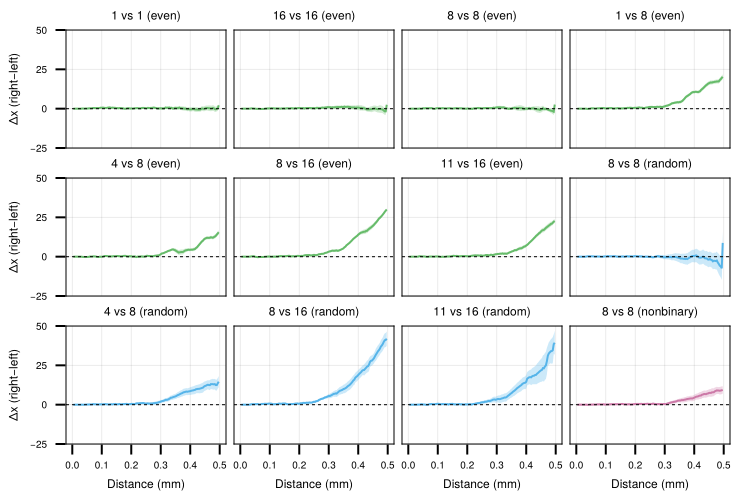


✓ Generated combined figure (13 cm wide)
  Saved: exploration_trajectories_combined_pnas_latest_5050.svg/.png
Figure size: 13.02 × 8.78 cm  (369 × 249 px)


In [55]:
# 6.1b VISUALIZATION: Create PNAS-style combined plot

using CairoMakie

println("\n" * "="^60)
println("Creating combined PNAS-style figure...")
println("="^60)

# Define experiment order (matching experimental_conditions from cell 5.1)
exp_order = [
    "1v1", "16ev16e", "8ev8e",
    "1v8e", "4ev8e", "8ev16e", "11ev16e",
    "8rv8r", "4rv8r", "8rv16r", "11rv16r",
    "8rv8r_nonbinary"
]

# Display names for plot titles
exp_display_names = Dict(
    "1v1" => "1 vs 1 (even)",
    "16ev16e" => "16 vs 16 (even)",
    "8ev8e" => "8 vs 8 (even)",
    "1v8e" => "1 vs 8 (even)",
    "4ev8e" => "4 vs 8 (even)",
    "8ev16e" => "8 vs 16 (even)",
    "11ev16e" => "11 vs 16 (even)",
    "8rv8r" => "8 vs 8 (random)",
    "4rv8r" => "4 vs 8 (random)",
    "8rv16r" => "8 vs 16 (random)",
    "11rv16r" => "11 vs 16 (random)",
    "8rv8r_nonbinary" => "8 vs 8 (nonbinary)"
)

# Define colors by distribution type
function get_exp_color(exp_name::String)
    even_exps = Set(["1v1", "16ev16e", "8ev8e", "1v8e", "4ev8e", "8ev16e", "11ev16e"])
    if contains(exp_name, "nonbinary")
        return colorant"#CC79A7"
    elseif exp_name in even_exps
        return colorant"#66BB6A"
    else
        return colorant"#56B4E9"
    end
end

n_cols = 4
n_rows = ceil(Int, length(exp_order) / n_cols)

fig_width_px  = cm_to_px(13.0)
fig_height_px = fig_width_px * (n_rows / n_cols) * 0.9

fig_combined = Figure(
    size = (Int(round(fig_width_px)), Int(round(fig_height_px))),
    figure_padding = (4, 4, 4, 4)
)

for (idx, exp_name) in enumerate(exp_order)
    if !haskey(results_all, exp_name)
        @warn "Skipping $exp_name - not found in results"
        continue
    end

    results      = results_all[exp_name]
    exp_color    = get_exp_color(exp_name)
    display_name = exp_display_names[exp_name]

    row = div(idx - 1, n_cols) + 1
    col = mod(idx - 1, n_cols) + 1

    is_bottom = row == n_rows
    is_left   = col == 1

    sites_mm = results.site_indices ./ 300

    ax = Axis(fig_combined[row, col],
        title  = display_name,
        xlabel = is_bottom ? "Distance (mm)" : "",
        ylabel = is_left   ? "Δx (right−left)" : "",
        xticks = 0.0:0.1:0.5,
        yticks = [-25, 0, 25, 50],
        xlabelsize     = 6,
        ylabelsize     = 6,
        xticklabelsize = 5,
        yticklabelsize = 5,
        titlesize      = 6,
        spinewidth     = 0.5,
        xticksvisible      = is_bottom,
        xticklabelsvisible = is_bottom,
        xlabelvisible      = is_bottom,
        yticksvisible      = is_left,
        yticklabelsvisible = is_left,
        ylabelvisible      = is_left,
        xgridvisible  = true,
        ygridvisible  = true,
        xgridcolor    = RGBAf(0, 0, 0, 0.10),
        ygridcolor    = RGBAf(0, 0, 0, 0.10),
        xgridwidth    = 0.4,
        ygridwidth    = 0.4,
    )

    band!(ax, sites_mm, results.site_cis_low, results.site_cis_high,
        color = (exp_color, 0.3))

    lines!(ax, sites_mm, results.site_means,
        color     = exp_color,
        linewidth = 1.0)

    hlines!(ax, [0], color=:black, linestyle=:dash, linewidth=0.5)

    ylims!(ax, -25, 50)
end

# Tighten spacing between panels
colgap!(fig_combined.layout, 4)
rowgap!(fig_combined.layout, 4)

resize_to_layout!(fig_combined)
display(fig_combined)

save_svg(fig_combined, "exploration_trajectories_combined_pnas_latest_5050")
CairoMakie.save(joinpath(FIGDIR, "exploration_trajectories_combined_pnas_latest_5050.png"), fig_combined, px_per_unit=3)

println("\n✓ Generated combined figure (13 cm wide)")
println("  Saved: exploration_trajectories_combined_pnas_latest_5050.svg/.png")
sz = fig_combined.scene.viewport[].widths
println("Figure size: $(round(sz[1]/28.3465, digits=2)) × $(round(sz[2]/28.3465, digits=2)) cm  ($(sz[1]) × $(sz[2]) px)")

In [102]:
# 6.3 Analyze which replicates reached high-quality (right) arm first
# For uneven experiments, determine when biomass first reaches each end
# Analyzing data from: Bandit_experiments_cleaned

using Printf

println("="^70)
println("ANALYZING ARM REACH TIMING FOR UNEVEN EXPERIMENTS")
println("Data source: Bandit_experiments_cleaned")
println("="^70)

# Define uneven (asymmetric) experimental conditions
# Labels match folder names in Bandit_experiments_cleaned
uneven_conditions = [
    (1, 8, "even", "1v8e"),
    (4, 8, "even", "4ev8e"),
    (8, 16, "even", "8ev16e"),
    (11, 16, "even", "11ev16e"),
    (4, 8, "random", "4rv8r"),
    (8, 16, "random", "8rv16r"),
    (11, 16, "random", "11rv16r"),
    (8, 8, "nonbinary", "8rv8r_nonbinary")
]

# Thresholds for detecting presence
h_threshold = 0.001  # Thickness threshold for detecting biomass
left_end_range = 1:10       # Far left positions (first 10 grid points)
right_end_range = 291:300   # Far right positions (last 10 grid points)

# Storage for results
arm_reach_results = Dict()

# Analyze each uneven condition
for (lf, rf, distribution, label) in uneven_conditions
    println("\n" * "-"^70)
    println("Condition: $label ($lf vs $rf, $distribution)")
    println("-"^70)
    
    # Storage for this condition
    reached_right_first = Int[]
    reached_left_first = Int[]
    reached_both_same = Int[]
    no_reach = Int[]
    
    # Load from Bandit_experiments_cleaned
    output_dir = joinpath("Bandit_experiments_cleaned", label)
    
    if !isdir(output_dir)
        println("  ⚠ Directory not found: $output_dir")
        continue
    end
    
    # Analyze each replicate
    for rep = 1:30
        filename = joinpath(output_dir, "exp_$(rep).csv")
        
        if !isfile(filename)
            println("  ⚠ Missing replicate $rep")
            continue
        end
        
        # Load thickness data
        data = CSV.read(filename, DataFrame)
        times = data[:, 1]
        n_timesteps = length(times)
        
        # Extract thickness values for middle row across all x positions
        # Data structure: column 1 = time, columns 2:301 = row 1, 302:601 = row 2, 602:901 = row 3
        # We use row 2 (middle row) which is columns 302:601
        middle_row_start = Nx + 2
        middle_row_end = 2*Nx + 1
        thickness_data = Matrix(data[:, middle_row_start:middle_row_end])
        
        # Find first time reaching each end
        time_reached_left = nothing
        time_reached_right = nothing
        
        for t = 1:n_timesteps
            # Check left end
            if time_reached_left === nothing
                if maximum(thickness_data[t, left_end_range]) > h_threshold
                    time_reached_left = times[t]
                end
            end
            
            # Check right end
            if time_reached_right === nothing
                if maximum(thickness_data[t, right_end_range]) > h_threshold
                    time_reached_right = times[t]
                end
            end
            
            # Break if both reached
            if time_reached_left !== nothing && time_reached_right !== nothing
                break
            end
        end
        
        # Categorize this replicate
        if time_reached_left === nothing && time_reached_right === nothing
            push!(no_reach, rep)
        elseif time_reached_right !== nothing && time_reached_left === nothing
            push!(reached_right_first, rep)
        elseif time_reached_left !== nothing && time_reached_right === nothing
            push!(reached_left_first, rep)
        elseif time_reached_right < time_reached_left
            push!(reached_right_first, rep)
        elseif time_reached_left < time_reached_right
            push!(reached_left_first, rep)
        else
            push!(reached_both_same, rep)
        end
    end
    
    # Store results
    arm_reach_results[label] = Dict(
        "right_first" => reached_right_first,
        "left_first" => reached_left_first,
        "both_same" => reached_both_same,
        "no_reach" => no_reach,
        "lf" => lf,
        "rf" => rf
    )
    
    # Print summary
    n_analyzed = length(reached_right_first) + length(reached_left_first) + 
                 length(reached_both_same) + length(no_reach)
    pct_right = length(reached_right_first) / n_analyzed * 100
    
    println("\nResults:")
    println("  Reached RIGHT (high-quality) first: $(length(reached_right_first)) replicates ($(round(pct_right, digits=1))%)")
    println("  Reached LEFT (low-quality) first:   $(length(reached_left_first)) replicates")
    println("  Reached both simultaneously:        $(length(reached_both_same)) replicates")
    println("  Neither end reached:                $(length(no_reach)) replicates")
    println("\n  Expected ratio (R:L food sources): $(rf):$(lf) = $(round(rf/lf, digits=2))")
end

println("\n" * "="^70)
println("SUMMARY TABLE")
println("="^70)
println(@sprintf("%-20s %6s %6s %6s %10s", "Condition", "→R", "←L", "Ratio", "Expected"))
println("-"^70)

for (label, results) in sort(collect(arm_reach_results), by = first)
    n_right = length(results["right_first"])
    n_left = length(results["left_first"])
    ratio = n_left > 0 ? n_right / n_left : Inf
    expected = results["rf"] / results["lf"]
    
    println(@sprintf("%-20s %6d %6d %6.2f %10.2f", 
            label, n_right, n_left, ratio, expected))
end

println("="^70)
println("✓ Analysis complete")
println("  Legend: →R = reached right first, ←L = reached left first")
println("  Detection: thickness > $h_threshold at positions 1-10 (left) or 291-300 (right)")

ANALYZING ARM REACH TIMING FOR UNEVEN EXPERIMENTS
Data source: Bandit_experiments_cleaned

----------------------------------------------------------------------
Condition: 1v8e (1 vs 8, even)
----------------------------------------------------------------------

Results:
  Reached RIGHT (high-quality) first: 30 replicates (100.0%)
  Reached LEFT (low-quality) first:   0 replicates
  Reached both simultaneously:        0 replicates
  Neither end reached:                0 replicates

  Expected ratio (R:L food sources): 8:1 = 8.0

----------------------------------------------------------------------
Condition: 4ev8e (4 vs 8, even)
----------------------------------------------------------------------

Results:
  Reached RIGHT (high-quality) first: 30 replicates (100.0%)
  Reached LEFT (low-quality) first:   0 replicates
  Reached both simultaneously:        0 replicates
  Neither end reached:                0 replicates

  Expected ratio (R:L food sources): 8:4 = 2.0

----------------


Creating directional preference bar chart...
Plotting 8 conditions


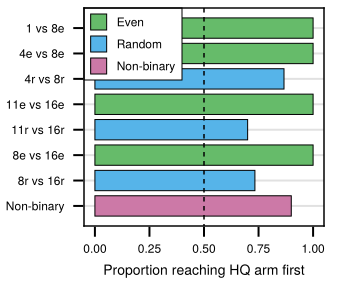


Percentage reaching HQ (right) arm first:
  1 vs 8e: 100.0%
  4e vs 8e: 100.0%
  4r vs 8r: 86.7%
  11e vs 16e: 100.0%
  11r vs 16r: 70.0%
  8e vs 16e: 100.0%
  8r vs 16r: 73.3%
  Non-binary: 90.0%

✓ Generated PNAS-style bar chart
  Saved: directional_preference_pnas.svg
  Saved: directional_preference_pnas.png
  Size: 6.0 cm width (single column)
  Size: 6.0 cm width (single column)


In [106]:
# 6.2 VISUALIZATION: Directional preference bar chart (PNAS-style)

using CairoMakie

println("\n" * "="^60)
println("Creating directional preference bar chart...")
println("="^60)

# Define experiment order (as requested)
exp_order = ["1v8e", "4ev8e", "4rv8r", "11ev16e", "11rv16r", "8ev16e", "8rv16r", "8rv8r_nonbinary"]

# Display names (matching trajectory plot)
exp_display_names = Dict(
    "1v8e" => "1 vs 8e",
    "4ev8e" => "4e vs 8e",
    "8ev16e" => "8e vs 16e",
    "11ev16e" => "11e vs 16e",
    "4rv8r" => "4r vs 8r",
    "8rv16r" => "8r vs 16r",
    "11rv16r" => "11r vs 16r",
    "8rv8r_nonbinary" => "Non-binary"
)

# Color scheme by distribution type
color_even = colorant"#66BB6A"       # Green for even
color_random = colorant"#56B4E9"     # Light blue for random
color_nonbinary = colorant"#CC79A7"  # Light purple for nonbinary

# Prepare data arrays
n_conditions = length(exp_order)
condition_names = Vector{String}(undef, n_conditions)
hq_percentages = Vector{Float64}(undef, n_conditions)
bar_colors = Vector{Any}(undef, n_conditions)

# Process all conditions in order using arm_reach_results from cell 27
for (idx, exp_name) in enumerate(exp_order)
    if haskey(arm_reach_results, exp_name)
        results = arm_reach_results[exp_name]
        n_right = length(results["right_first"])
        n_left = length(results["left_first"])
        n_total = n_right + n_left + length(results["both_same"]) + length(results["no_reach"])
        
        condition_names[idx] = exp_display_names[exp_name]
        hq_percentages[idx] = n_right / n_total  # Proportion, not percentage
        
        # Assign color based on distribution type
        # Even distributions end with "e", random with "r", nonbinary contains "nonbinary"
        if contains(exp_name, "nonbinary")
            bar_colors[idx] = color_nonbinary
        elseif endswith(exp_name, "e")
            bar_colors[idx] = color_even
        else  # ends with "r" for random
            bar_colors[idx] = color_random
        end
    else
        @warn "No data found for $exp_name"
    end
end

n_plotted = n_conditions

println("Plotting $n_plotted conditions")

# PNAS specifications — horizontal bar chart
pnas_width_cm  = 6.0
pnas_height_cm = 5.0
pnas_width_px  = cm_to_px(pnas_width_cm)
pnas_height_px = cm_to_px(pnas_height_cm)

# Create figure with PNAS styling
fig_bar = Figure(size=(Int(round(pnas_width_px)), Int(round(pnas_height_px))),
                 figure_padding=(4, 8, 4, 4))

ax = Axis(fig_bar[1, 1],
    ylabel="",
    xlabel="Proportion reaching HQ arm first",
    yticks=(1:n_plotted, condition_names),
    xticks=0.0:0.25:1.0,
    xlabelsize=7,
    ylabelsize=7,
    xticklabelsize=6,
    yticklabelsize=6,
    spinewidth=0.75,
    xgridvisible=false,
    yreversed=true)   # top condition = index 1

# Horizontal bars
barplot!(ax, 1:n_plotted, hq_percentages,
    direction=:x,
    color=bar_colors,
    strokecolor=:black,
    strokewidth=0.5)

# Reference line at chance level
vlines!(ax, [0.5], color=:black, linestyle=:dash, linewidth=0.75)

# Legend — top-left corner inside the plot
Legend(fig_bar[1, 1],
    [PolyElement(color=color_even,      strokecolor=:black, strokewidth=0.5),
     PolyElement(color=color_random,    strokecolor=:black, strokewidth=0.5),
     PolyElement(color=color_nonbinary, strokecolor=:black, strokewidth=0.5)],
    ["Even", "Random", "Non-binary"],
    labelsize=6,
    framevisible=true,
    framewidth=0.5,
    padding=(3, 3, 3, 3),
    patchsize=(8, 8),
    tellwidth=false,
    tellheight=false,
    halign=:left,
    valign=:top)

display(fig_bar)

# Save figure
save_svg(fig_bar, "directional_preference_pnas_smaller")
CairoMakie.save(joinpath(FIGDIR, "directional_preference_pnas_smaller.png"), fig_bar, px_per_unit=3)

# Print statistics
println("\nPercentage reaching HQ (right) arm first:")
for (i, name) in enumerate(condition_names)
    println("  $name: $(round(hq_percentages[i] * 100, digits=1))%")
end
println("\n✓ Generated PNAS-style bar chart")
println("  Saved: directional_preference_pnas.svg")
println("  Saved: directional_preference_pnas.png") 
println("  Size: $(pnas_width_cm) cm width (single column)")
println("  Size: $(pnas_width_cm) cm width (single column)")